# House Price Prediction — 1. Exploratory Data Analysis
**Dataset:** Zameen.com Pakistan House Price Dataset (`zameen-updated.csv`)

**Goal:** Understand the structure, quality, and distributions in the data before any cleaning or modeling.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv(r'D:\Internship\house prediction\zameen-updated.csv',encoding = "latin1")
print(df.shape)
df.head()

(168446, 20)


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla


## 1. Basic Structure & Missing Values

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  object 
 3   property_type  168446 non-null  object 
 4   price          168446 non-null  int64  
 5   location       168446 non-null  object 
 6   city           168446 non-null  object 
 7   province_name  168446 non-null  object 
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  object 
 12  purpose        168446 non-null  object 
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  object 
 15  agency         124375 non-null  object 
 16  agent          124374 non-null  object 
 17  Area Type      168446 non-nul

In [4]:
missing = df.isnull().sum()
missing[missing > 0]

agency    44071
agent     44072
dtype: int64

`agency` and `agent` have many missing values — these are not useful for price prediction (they're listing metadata, not property attributes), so we'll drop them in preprocessing.

## 2. Purpose: For Sale vs For Rent

In [5]:
print(df['purpose'].value_counts())
print()
print(df.groupby('purpose')['price'].describe())

purpose
For Sale    120655
For Rent     47791
Name: count, dtype: int64

             count          mean           std  min        25%         50%  \
purpose                                                                      
For Rent   47791.0  9.488438e+04  1.759586e+05  0.0    28500.0     45000.0   
For Sale  120655.0  2.476513e+07  3.959754e+07  0.0  7400000.0  13500000.0   

                 75%           max  
purpose                             
For Rent     89000.0  1.250000e+07  
For Sale  26000000.0  2.000000e+09  


**Important finding:** "For Rent" prices are monthly rent amounts (median ~PKR 35,000) while "For Sale" prices are property sale prices (median ~PKR 8.5M). These are two completely different price scales and cannot be modeled together.

Since the task is **house price prediction** (not rent prediction), we will keep only `purpose == 'For Sale'` listings going forward.

In [6]:
df_sale = df[df['purpose'] == 'For Sale'].copy()
print(df_sale.shape)


(120655, 20)


## 3. Price Distribution (For Sale only)

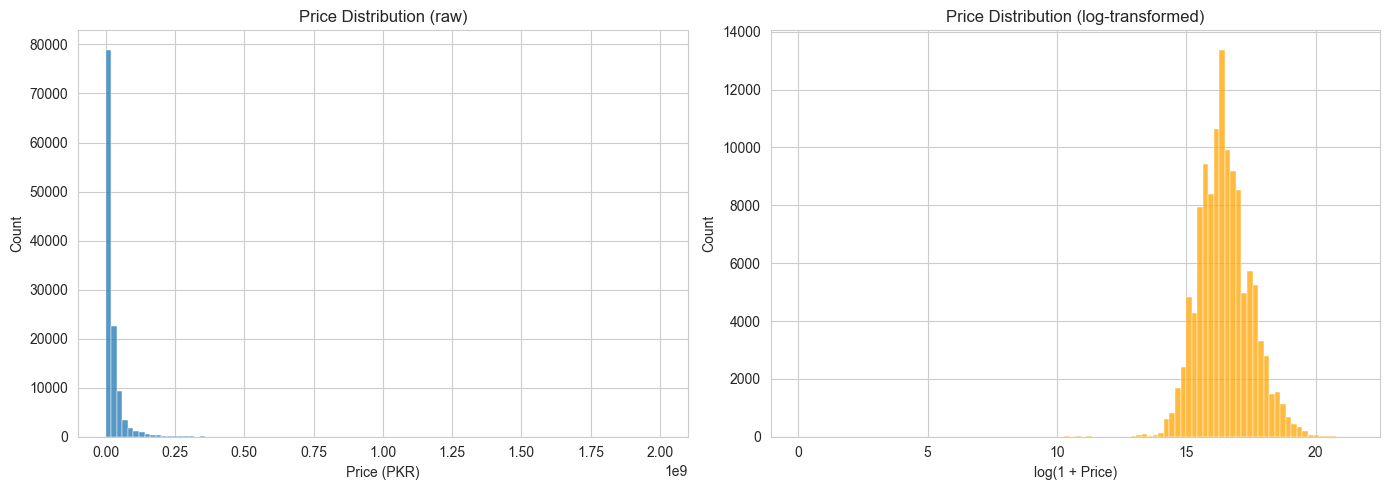

count    1.206550e+05
mean     2.476513e+07
std      3.959754e+07
min      0.000000e+00
25%      7.400000e+06
50%      1.350000e+07
75%      2.600000e+07
max      2.000000e+09
Name: price, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_sale['price'], bins=100, ax=axes[0])
axes[0].set_title('Price Distribution (raw)')
axes[0].set_xlabel('Price (PKR)')

sns.histplot(np.log1p(df_sale['price']), bins=100, ax=axes[1], color='orange')
axes[1].set_title('Price Distribution (log-transformed)')
axes[1].set_xlabel('log(1 + Price)')
plt.tight_layout()
plt.show()

print(df_sale['price'].describe())

The raw price is heavily right-skewed (a small number of very expensive properties stretch the distribution). The log-transformed price is much closer to a normal distribution — this is a strong signal that we should **train the model on `log(price)`** rather than raw price, then exponentiate predictions back.

## 4. Property Type & City

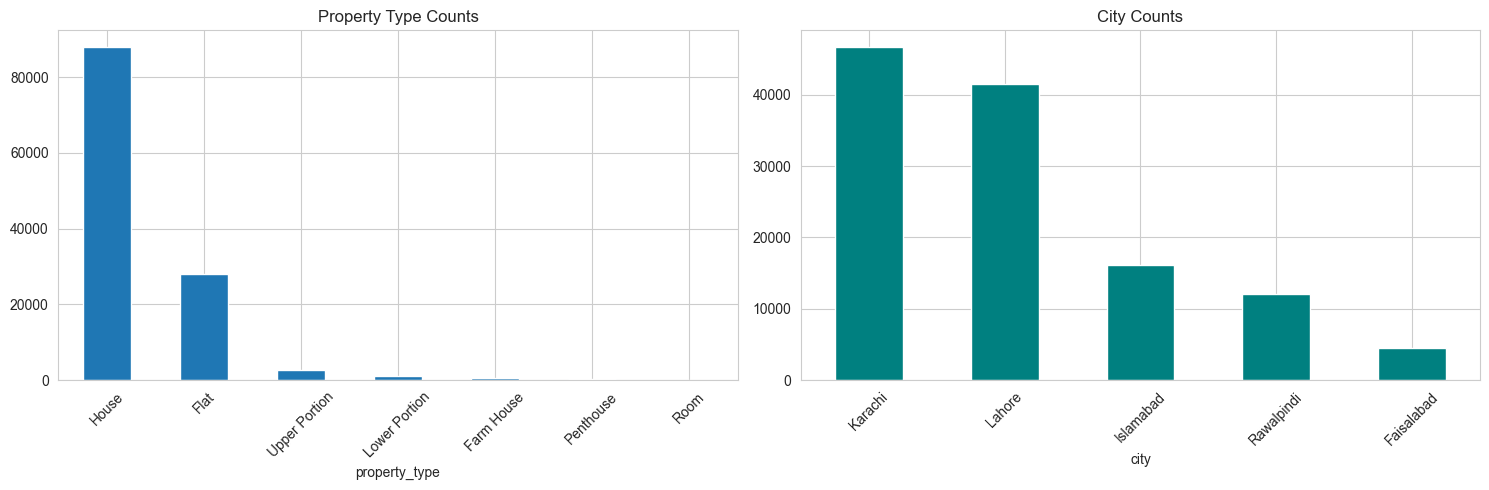

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_sale['property_type'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title('Property Type Counts')
axes[0].tick_params(axis='x', rotation=45)

df_sale['city'].value_counts().plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('City Counts')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

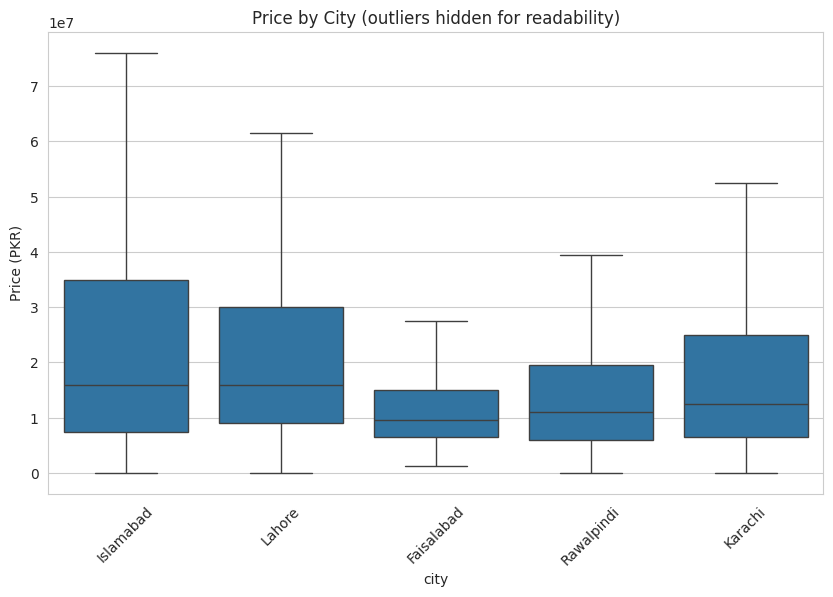

In [8]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_sale, x='city', y='price', showfliers=False)
plt.title('Price by City (outliers hidden for readability)')
plt.ylabel('Price (PKR)')
plt.xticks(rotation=45)
plt.show()

Karachi, Lahore and Islamabad clearly differ in price level — `city` is a strong predictive feature.

## 5. Area: Marla vs Kanal

In [9]:
print(df_sale['Area Type'].value_counts())
print()
print(df_sale.groupby('Area Type')['Area Size'].describe())

Area Type
Marla    102158
Kanal     18497
Name: count, dtype: int64

              count      mean       std  min  25%  50%  75%    max
Area Type                                                         
Kanal       18497.0  1.792777  7.475785  1.0  1.0  1.0  1.3  600.0
Marla      102158.0  6.576612  3.297379  0.0  4.2  5.0  9.4   20.0


Area is recorded in two different units: **Marla** and **Kanal** (1 Kanal = 20 Marla). These must be converted to a single consistent unit before they can be used as one numeric feature — we'll do this in preprocessing.

## 6. Bedrooms & Bathrooms

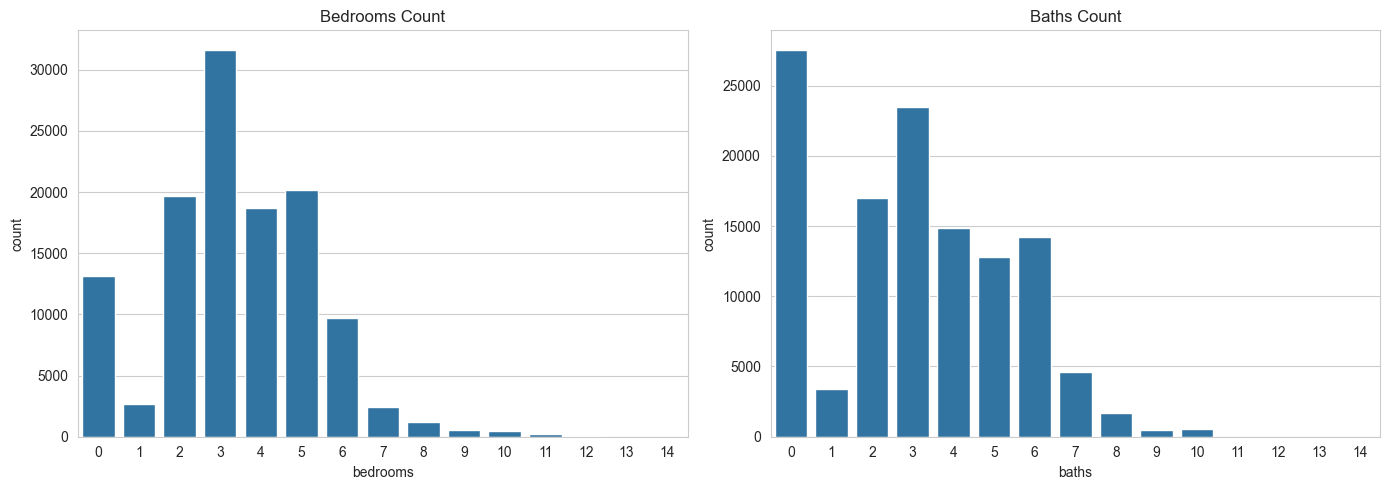

Listings with 0 bedrooms: 13119
Listings with 0 baths: 27554


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df_sale, x='bedrooms', ax=axes[0], order=sorted(df_sale['bedrooms'].unique())[:15])
axes[0].set_title('Bedrooms Count')
sns.countplot(data=df_sale, x='baths', ax=axes[1], order=sorted(df_sale['baths'].unique())[:15])
axes[1].set_title('Baths Count')
plt.tight_layout()
plt.show()

print('Listings with 0 bedrooms:', (df_sale['bedrooms']==0).sum())
print('Listings with 0 baths:', (df_sale['baths']==0).sum())

Zero bedrooms/baths mostly correspond to plots of land or commercial-style listings rather than missing data — we'll keep these but treat them carefully during outlier filtering.

## 7. Geographic Spread (Latitude/Longitude)

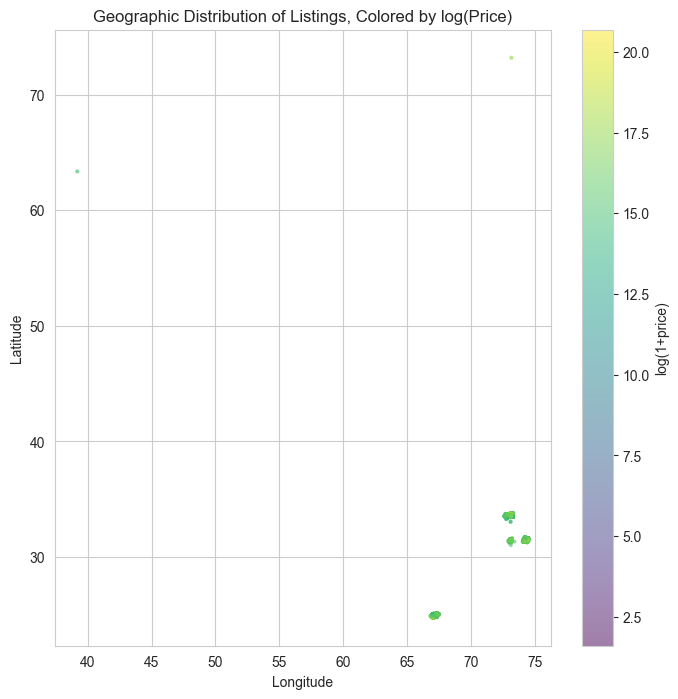

In [11]:
plt.figure(figsize=(8,8))
sample = df_sale.sample(min(20000, len(df_sale)), random_state=42)
sc = plt.scatter(sample['longitude'], sample['latitude'], c=np.log1p(sample['price']),
                  cmap='viridis', s=4, alpha=0.5)
plt.colorbar(sc, label='log(1+price)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Listings, Colored by log(Price)')
plt.show()

## 8. Correlation Between Numeric Features

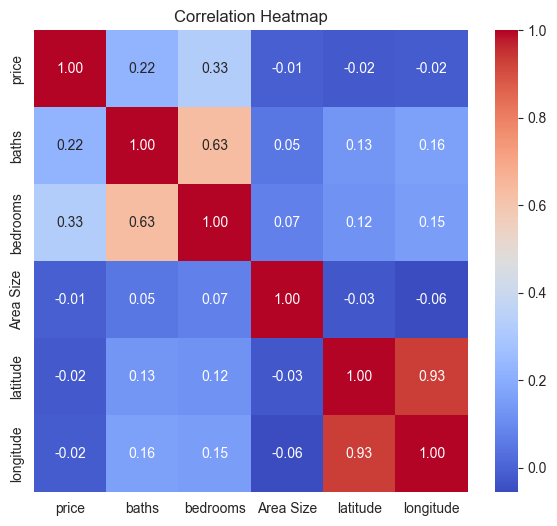

In [12]:
numeric_cols = ['price', 'baths', 'bedrooms', 'Area Size', 'latitude', 'longitude']
corr = df_sale[numeric_cols].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

Note: `Area Size` alone isn't fully comparable across rows yet since it mixes Marla and Kanal units — correlation will become more meaningful after unit conversion in preprocessing.

## Summary of EDA Findings

1. Filter to `purpose == 'For Sale'` only — rent and sale prices are incompatible scales.
2. Price is heavily right-skewed → model on `log(price)`.
3. `city` and `location` strongly affect price.
4. Area is split across Marla/Kanal units → must unify before use.
5. `agency`/`agent` have heavy missingness and low predictive value → drop.
6. `bedrooms`/`baths` = 0 are valid (plots/land), not necessarily errors.
7. Latitude/longitude give a geographic signal in addition to city/location text.

Next: **02_preprocessing.ipynb**